In [ ]:
pip install pandas numpy matplotlib seaborn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load your pre-filtered ACLED data
df_acled = pd.read_csv('ACLED Data_2026-03-19.csv')

# Display the first few rows to confirm loading
display(df_acled.head())

,event_id_cnty,event_date,year,time_precision,disorder_type,event_type,sub_event_type,actor1,assoc_actor_1,inter1,...,location,latitude,longitude,geo_precision,source,source_scale,notes,fatalities,tags,timestamp
0,NIG2443,2010-01-03,2010,1,Political violence,Violence against civilians,Attack,Unidentified Armed Group (Nigeria),NaN,Political militia,...,Benin City,6.3351,5.6275,1,All Africa,International,Three unknown assassins break into the residen...,1,NaN,1552577624
1,NIG2444,2010-01-03,2010,1,Political violence,Violence against civilians,Attack,Unidentified Armed Group (Nigeria),NaN,Political militia,...,Warri,5.5167,5.7500,1,All Africa,International,A youth shot dead two other boys along Yoruba ...,2,NaN,1651165022
2,NIG2449,2010-01-04,2010,1,Political violence,Violence against civilians,Attack,Unidentified Armed Group (Nigeria),NaN,Political militia,...,Uwelu,6.3833,5.5833,1,All Africa,International,The traditional ruler of the Ugolo community i...,1,NaN,1552577624
3,NIG2447,2010-01-04,2010,1,Political violence,Violence against civilians,Attack,Kalo-Kato Militia,NaN,Political militia,...,Bauchi,10.3134,9.8433,2,All Africa,International,A total of 70 dead when an Islamic sect riots.,70,NaN,1552577624
4,NIG2448,2010-01-04,2010,1,Political violence,Violence against civilians,Attack,Unidentified Armed Group (Nigeria),NaN,Political militia,...,Benin City,6.3351,5.6275,1,All Africa,International,A armed group attacks the PDP Chief whip prior...,0,NaN,1552577624


### Phase 1: Data Validation
Since you pre-filtered Country and Date on the portal, we just need to ensure pandas reads the date column correctly for our later steps.

In [ ]:
df_acled['event_date'] = pd.to_datetime(df_acled['event_date'])

# Display info to confirm date conversion
print(df_acled.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22478 entries, 0 to 22477
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   event_id_cnty       22478 non-null  object        
 1   event_date          22478 non-null  datetime64[ns]
 2   year                22478 non-null  int64         
 3   time_precision      22478 non-null  int64         
 4   disorder_type       22478 non-null  object        
 5   event_type          22478 non-null  object        
 6   sub_event_type      22478 non-null  object        
 7   actor1              22478 non-null  object        
 8   assoc_actor_1       4701 non-null   object        
 9   inter1              22478 non-null  object        
 10  actor2              21728 non-null  object        
 11  assoc_actor_2       7135 non-null   object        
 12  inter2              21728 non-null  object        
 13  interaction         22478 non-null  object    

### Phase 2: Thematic Filtering (The Academic Pivot)
Your CSV includes 'Battles', but the methodology requires us to isolate civil unrest. We will exclude 'Battles' here programmatically to leave an audit trail.

**Academic Justification (Notebook Note):** State-on-State military battles were excluded from this subset, as the primary objective is to measure civil unrest and localized violence directly correlated with economic grievances and food insecurity.

In [ ]:
thematic_types = ['Riots', 'Protests', 'Violence against civilians']
df_thematic = df_acled[df_acled['event_type'].isin(thematic_types)].copy()

# Display the first few rows of the thematic data
display(df_thematic.head())

,event_id_cnty,event_date,year,time_precision,disorder_type,event_type,sub_event_type,actor1,assoc_actor_1,inter1,...,location,latitude,longitude,geo_precision,source,source_scale,notes,fatalities,tags,timestamp
0,NIG2443,2010-01-03,2010,1,Political violence,Violence against civilians,Attack,Unidentified Armed Group (Nigeria),NaN,Political militia,...,Benin City,6.3351,5.6275,1,All Africa,International,Three unknown assassins break into the residen...,1,NaN,1552577624
1,NIG2444,2010-01-03,2010,1,Political violence,Violence against civilians,Attack,Unidentified Armed Group (Nigeria),NaN,Political militia,...,Warri,5.5167,5.7500,1,All Africa,International,A youth shot dead two other boys along Yoruba ...,2,NaN,1651165022
2,NIG2449,2010-01-04,2010,1,Political violence,Violence against civilians,Attack,Unidentified Armed Group (Nigeria),NaN,Political militia,...,Uwelu,6.3833,5.5833,1,All Africa,International,The traditional ruler of the Ugolo community i...,1,NaN,1552577624
3,NIG2447,2010-01-04,2010,1,Political violence,Violence against civilians,Attack,Kalo-Kato Militia,NaN,Political militia,...,Bauchi,10.3134,9.8433,2,All Africa,International,A total of 70 dead when an Islamic sect riots.,70,NaN,1552577624
4,NIG2448,2010-01-04,2010,1,Political violence,Violence against civilians,Attack,Unidentified Armed Group (Nigeria),NaN,Political militia,...,Benin City,6.3351,5.6275,1,All Africa,International,A armed group attacks the PDP Chief whip prior...,0,NaN,1552577624


### Phase 3: Spatial-Temporal Feature Engineering
Standardize temporal column to match WFP (using the 15th of the month) and rename the spatial column.

In [ ]:
df_processed_acled = df_acled.copy()
df_processed_acled['date'] = df_processed_acled['event_date'].dt.to_period('M').dt.to_timestamp() + pd.Timedelta(days=14)
df_processed_acled = df_processed_acled.rename(columns={'admin1': 'adm1_name'})

# Display info and head of the DataFrame to show new columns
print(df_processed_acled.info())
display(df_processed_acled.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22478 entries, 0 to 22477
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   event_id_cnty       22478 non-null  object        
 1   event_date          22478 non-null  datetime64[ns]
 2   year                22478 non-null  int64         
 3   time_precision      22478 non-null  int64         
 4   disorder_type       22478 non-null  object        
 5   event_type          22478 non-null  object        
 6   sub_event_type      22478 non-null  object        
 7   actor1              22478 non-null  object        
 8   assoc_actor_1       4701 non-null   object        
 9   inter1              22478 non-null  object        
 10  actor2              21728 non-null  object        
 11  assoc_actor_2       7135 non-null   object        
 12  inter2              21728 non-null  object        
 13  interaction         22478 non-null  object    

,event_id_cnty,event_date,year,time_precision,disorder_type,event_type,sub_event_type,actor1,assoc_actor_1,inter1,...,latitude,longitude,geo_precision,source,source_scale,notes,fatalities,tags,timestamp,date
0,NIG2443,2010-01-03,2010,1,Political violence,Violence against civilians,Attack,Unidentified Armed Group (Nigeria),NaN,Political militia,...,6.3351,5.6275,1,All Africa,International,Three unknown assassins break into the residen...,1,NaN,1552577624,2010-01-15
1,NIG2444,2010-01-03,2010,1,Political violence,Violence against civilians,Attack,Unidentified Armed Group (Nigeria),NaN,Political militia,...,5.5167,5.7500,1,All Africa,International,A youth shot dead two other boys along Yoruba ...,2,NaN,1651165022,2010-01-15
2,NIG2449,2010-01-04,2010,1,Political violence,Violence against civilians,Attack,Unidentified Armed Group (Nigeria),NaN,Political militia,...,6.3833,5.5833,1,All Africa,International,The traditional ruler of the Ugolo community i...,1,NaN,1552577624,2010-01-15
3,NIG2447,2010-01-04,2010,1,Political violence,Violence against civilians,Attack,Kalo-Kato Militia,NaN,Political militia,...,10.3134,9.8433,2,All Africa,International,A total of 70 dead when an Islamic sect riots.,70,NaN,1552577624,2010-01-15
4,NIG2448,2010-01-04,2010,1,Political violence,Violence against civilians,Attack,Unidentified Armed Group (Nigeria),NaN,Political militia,...,6.3351,5.6275,1,All Africa,International,A armed group attacks the PDP Chief whip prior...,0,NaN,1552577624,2010-01-15


### Phase 4: Data Aggregation (Creating the "Conflict Index")
Roll up the daily events into monthly State summaries.

In [ ]:
conflict_master = df_processed_acled.groupby(['date', 'adm1_name']).agg(
    battle_count=('event_type', lambda x: (x == 'Battles').sum()),
    riot_count=('event_type', lambda x: x.isin(['Riots', 'Protests']).sum()),
    conflict_intensity=('fatalities', 'sum'),
    avg_latitude=('latitude', 'mean'),
    avg_longitude=('longitude', 'mean')
).reset_index()

# Display the aggregated data
display(conflict_master.head())

,date,adm1_name,battle_count,riot_count,conflict_intensity,avg_latitude,avg_longitude
0,2010-01-15,Abia,0,0,0,5.5342,7.8893
1,2010-01-15,Anambra,0,0,0,6.1100,7.0724
2,2010-01-15,Bauchi,1,0,73,10.3134,9.8433
3,2010-01-15,Bayelsa,0,1,0,4.9247,6.2642
4,2010-01-15,Benue,1,0,6,7.7411,8.5121


### Phase 5: The "Data Audit Trail"
Print data attrition audit to see how many records were processed at each step.

In [ ]:
print("Data Attrition Audit:")
print(f"1. Raw ACLED Data (Pre-filtered via UI and event_date converted): {len(df_acled)} records")
print(f"2. Records processed for aggregation (after date/admin processing): {len(df_processed_acled)} records")
print(f"3. Final Aggregated Index Rows: {len(conflict_master)} records")

Data Attrition Audit:
1. Raw ACLED Data (Pre-filtered via UI and event_date converted): 22478 records
2. Records processed for aggregation (after date/admin processing): 22478 records
3. Final Aggregated Index Rows: 4169 records


### Visualization
Visualizing Conflict Frequency over time to validate the data.

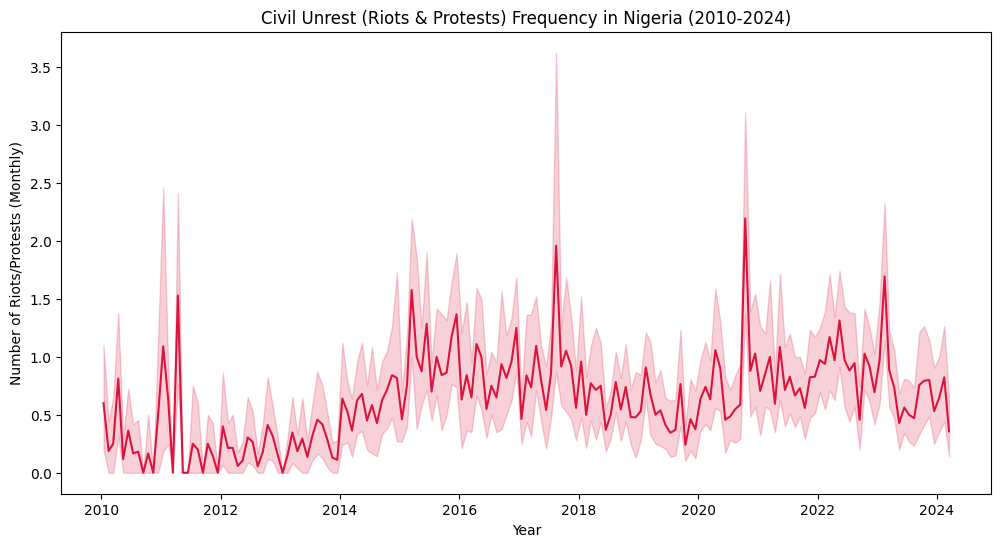

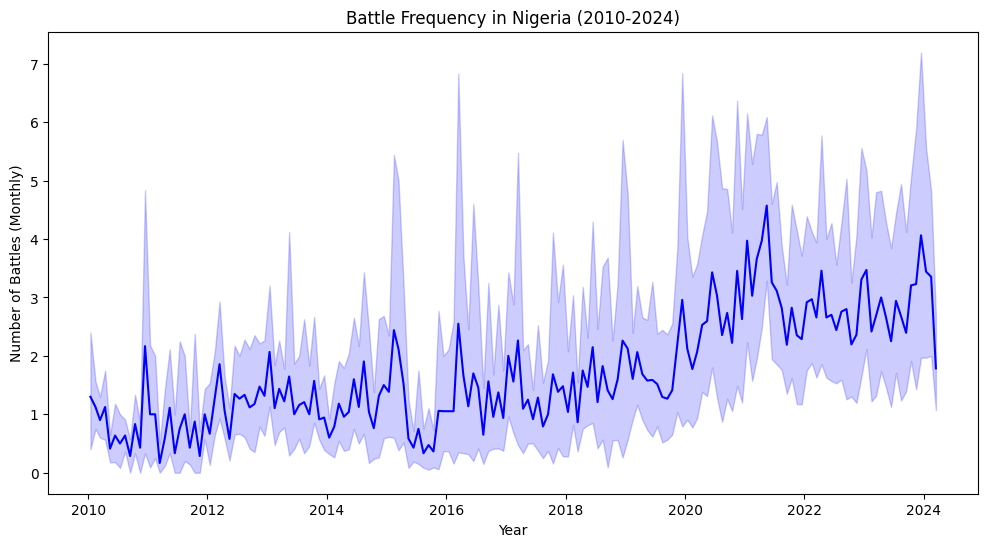

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=conflict_master, x='date', y='riot_count', color='crimson')
plt.title("Civil Unrest (Riots & Protests) Frequency in Nigeria (2010-2024)")
plt.xlabel("Year")
plt.ylabel("Number of Riots/Protests (Monthly)")
plt.show()

plt.figure(figsize=(12, 6))
sns.lineplot(data=conflict_master, x='date', y='battle_count', color='blue')
plt.title("Battle Frequency in Nigeria (2010-2024)")
plt.xlabel("Year")
plt.ylabel("Number of Battles (Monthly)")
plt.show()

### Export for Phase 3 Join
Exporting the processed data to a CSV file.

In [ ]:
output_path = "02_ACLED_Nigeria_clean.csv"
conflict_master.to_csv(output_path, index=False)
print(f"\n✅ File successfully saved to: {output_path}")


✅ File successfully saved to: 02_ACLED_Nigeria_clean.csv
